In [108]:
import sys
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

this_path = Path(__file__) if '__file__' in globals() else Path("<unknown>.ipynb").resolve()
work_path = next((p for p in this_path.parents if p.name == "research"), None)
tools_path = work_path / Path("../torch-tools")
sys.path.append(str(tools_path))

from run_manager import RunViewer


In [109]:
rv = RunViewer(exp_path=this_path.parent)
df_base = rv.fetch_results(met_listed=True, refresh=True)

nested_columns = [name for name, dtype in zip(df_base.columns, df_base.dtypes) if dtype.is_nested()]
df_base = df_base.with_columns([pl.col(name).list.last().alias(f"{name}") for name in nested_columns])

# display(df_base)

In [100]:
df_base = df_base.with_columns(pl.Series("fils", [32, 32, 4, 4, 32, 32, 4, 4]))
df_base = df_base.with_columns(pl.Series("ensembles", [1, 1, 64, 64, 1, 1, 64, 64]))
df_base = df_base.with_columns(pl.lit(32).alias("base_fils"))
df_base = df_base.select(['run_id', 'model_arc', 'train_dataset', 'val_dataset', 'num_classes', 'train_trans', 'val_trans', 'train_ndata', 'val_ndata', 'epochs', 'max_lr', 'batch_size', 'iters/epoch', 'iters', 'target_steps', 'ndata_per_class', 'fils', 'ensembles', 'base_fils', 'criterion', 'optimizer', 'scheduler', 'step', 'epoch', 'train_loss', 'train_acc', 'train_path_loss', 'train_path_acc', 'timestamp', 'timestamp_fmt', 'duration', 'duration_fmt', 'dur_total_core', 'dur_train_core', 'dur_dl_train', 'val_loss', 'val_acc', 'val_path_loss', 'val_path_acc'])
display(df_base)

run_id,model_arc,train_dataset,val_dataset,num_classes,train_trans,val_trans,train_ndata,val_ndata,epochs,max_lr,batch_size,iters/epoch,iters,target_steps,ndata_per_class,fils,ensembles,base_fils,criterion,optimizer,scheduler,step,epoch,train_loss,train_acc,train_path_loss,train_path_acc,timestamp,timestamp_fmt,duration,duration_fmt,dur_total_core,dur_train_core,dur_dl_train,val_loss,val_acc,val_path_loss,val_path_acc
i64,str,str,str,i64,str,str,i64,i64,i64,f64,i64,i64,i64,i64,f64,i64,i64,i32,str,str,str,i64,i64,f64,f64,list[f64],list[f64],f64,str,f64,str,f64,f64,f64,f64,f64,list[f64],list[f64]
0,"""ee_tools.models.resnet_git_ee …","""cifar100_train""","""cifar100_val""",100,"""[ToImage(), RandomCrop(size=(3…","""[ToImage(), ToDtype(scale=True…",5000,10000,200,0.1,128,40,8000,1000000,50.0,32,1,32,"""CrossEntropyLoss""","""SGD""","""CosineAnnealingLR""",200,200,0.411827,0.8804,[0.411827],[0.8804],1.7491e9,"""2025/06/05 05:44:45""",3387.175679,"""56.5m""",120.023686,93.660834,13.453611,4.661618,0.2831,[4.661618],[0.2831]
1,"""ee_tools.models.resnet_git_ee …","""cifar100_train""","""cifar100_val""",100,"""[ToImage(), RandomCrop(size=(3…","""[ToImage(), ToDtype(scale=True…",5000,10000,200,0.005,128,40,8000,1000000,50.0,32,1,32,"""CrossEntropyLoss""","""Adam""","""CosineAnnealingLR""",200,200,0.149137,0.959,[0.149137],[0.959],1.7491e9,"""2025/06/05 05:44:45""",3387.175679,"""56.5m""",118.544039,93.369518,13.453611,7.937569,0.2359,[7.937569],[0.2359]
2,"""ee_tools.models.resnet_git_ee …","""cifar100_train""","""cifar100_val""",100,"""[ToImage(), RandomCrop(size=(3…","""[ToImage(), ToDtype(scale=True…",5000,10000,200,0.1,128,40,8000,1000000,50.0,4,64,32,"""CrossEntropyLoss""","""SGD""","""CosineAnnealingLR""",200,200,3.217666,0.2754,"[7.328719, 5.446736, … 7.448616]","[0.0112, 0.0174, … 0.017]",1.7491e9,"""2025/06/05 05:44:45""",3387.175679,"""56.5m""",1549.436682,1128.735981,13.453611,3.414633,0.1852,"[7.216468, 5.246809, … 9.455979]","[0.0112, 0.0184, … 0.0194]"
3,"""ee_tools.models.resnet_git_ee …","""cifar100_train""","""cifar100_val""",100,"""[ToImage(), RandomCrop(size=(3…","""[ToImage(), ToDtype(scale=True…",5000,10000,200,0.005,128,40,8000,1000000,50.0,4,64,32,"""CrossEntropyLoss""","""Adam""","""CosineAnnealingLR""",200,200,0.236361,0.9302,"[72.911387, 94.904865, … 75.33529]","[0.0128, 0.0206, … 0.0184]",1.7491e9,"""2025/06/05 05:44:45""",3387.175679,"""56.5m""",1537.02794,1127.226044,13.453611,5.511995,0.3175,"[111.834195, 119.552911, … 101.563949]","[0.0117, 0.017, … 0.0144]"
4,"""ee_tools.models.resnet_git_ee …","""cifar100_train""","""cifar100_val""",100,"""[ToImage(), RandomCrop(size=(3…","""[ToImage(), ToDtype(scale=True…",1000,10000,1000,0.1,128,8,8000,1000000,10.0,32,1,32,"""CrossEntropyLoss""","""SGD""","""CosineAnnealingLR""",1000,1000,0.007005,1.0,[0.007005],[1.0],1.7491e9,"""2025/06/05 06:41:58""",3432.635199,"""57.2m""",120.885393,95.598346,61.466164,4.100592,0.154,[4.100592],[0.154]
5,"""ee_tools.models.resnet_git_ee …","""cifar100_train""","""cifar100_val""",100,"""[ToImage(), RandomCrop(size=(3…","""[ToImage(), ToDtype(scale=True…",1000,10000,1000,0.005,128,8,8000,1000000,10.0,32,1,32,"""CrossEntropyLoss""","""Adam""","""CosineAnnealingLR""",1000,1000,0.012928,0.997,[0.012928],[0.997],1.7491e9,"""2025/06/05 06:41:58""",3432.635199,"""57.2m""",116.268494,91.995331,61.466164,14.386215,0.1187,[14.386215],[0.1187]
6,"""ee_tools.models.resnet_git_ee …","""cifar100_train""","""cifar100_val""",100,"""[ToImage(), RandomCrop(size=(3…","""[ToImage(), ToDtype(scale=True…",1000,10000,1000,0.1,128,8,8000,1000000,10.0,4,64,32,"""CrossEntropyLoss""","""SGD""","""CosineAnnealingLR""",1000,1000,0.856438,0.919,"[9.796702, 8.271714, … 7.456322]","[0.02, 0.017, … 0.017]",1.7491e9,"""2025/06/05 06:41:58""",3432.635199,"""57.2m""",1493.497861,1091.42142,61.466164,4.151652,0.1274,"[11.080438, 7.771927, … 18.215843]","[0.0182, 0.0166, … 0.0168]"
7,"""ee_tools.models.resnet_git_ee …","""cifar100_train""","""cifar100_val""",100,"""[To

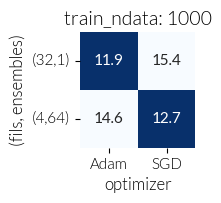

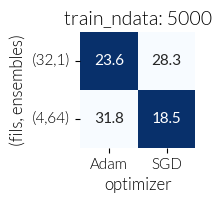

In [101]:
df = df_base

# df = df.filter(pl.col("fils").is_in([32, 16, 8, 4]))

# piv_values = ["train_acc"] # 表示する値
piv_values = ["val_acc"] # 表示する値
piv_index = ["fils", "ensembles"] # 縦軸
piv_on = "optimizer" # 横軸

# agg = "len"
agg = "mean"

ext_column = "train_ndata" # このカラムの要素ごとにheatmapを表示

ext_l = df[ext_column].unique()
for ext in ext_l:
    # pivot table 作成
    df_ext = df.filter(pl.col(ext_column) == ext)
    df_piv = df_ext.pivot(values=piv_values, index=piv_index, on=piv_on, sort_columns=True, aggregate_function=agg)

    # カラムが文字列順になっているため、数字部分をソート
    _num_columns = sorted(int(x) for x in df_piv.columns if x.isdigit())
    new_columns = [str(_num_columns.pop(0)) if x.isdigit() else x for x in df_piv.columns]
    df_piv = df_piv.select(new_columns)

    # (fil, ensemble) の形式に
    df_piv = df_piv.with_columns(("(" + pl.col("fils").cast(pl.String) + "," + pl.col("ensembles").cast(pl.String)).alias("(fils, ensembles)") + ")")
    df_piv = df_piv.select(["(fils, ensembles)"] + new_columns).select(pl.exclude(["fils", "ensembles"]))
    
    # 0列目がx軸ラベル、1列目以降がy軸ラベルになる df を heat map に変換
    square_size = 0.75
    hm_x = df_piv.columns[1:]
    hm_y = df_piv[df_piv.columns[0]]
    data = df_piv.select(hm_x).to_numpy()
    annot = data.copy()

    # 正規化の方向を設定
    axis = 1    # 0: 行方向, 1: 列方向

    # min-max 正規化
    # min_vals = data.min(axis=axis, keepdims=True)
    # max_vals = data.max(axis=axis, keepdims=True)
    # data = (data - min_vals) / (max_vals - min_vals + 1e-8)  # ゼロ除算対策
    
    # Zスコア正規化
    mean_vals = data.mean(axis=axis, keepdims=True)
    std_vals = data.std(axis=axis, keepdims=True)
    data = (data - mean_vals) / (std_vals + 1e-8)  # ゼロ除算対策

    annot *= 100

    fig, ax = plt.subplots(figsize=(len(hm_x)*square_size, len(hm_y)*square_size))

    fontname = "Lato"
    fontweight = 300  # ここで整数のweightを指定

    hm_kwargs = {
        "cmap": "Blues_r",
        "cbar": False,
        "fmt": ".1f",
        "annot_kws": {"size": 11, "fontname": fontname, "fontweight": 500}
    }

    ax = sns.heatmap(data, annot=annot, square=True, **hm_kwargs)

    ax.set_title(f"{ext_column}: {ext}", fontsize=14, fontname=fontname, fontweight=fontweight)
    ax.set_xlabel(piv_on, fontsize=12, fontname=fontname, fontweight=fontweight)
    ax.set_ylabel(hm_y.name, fontsize=12, rotation=90, fontname=fontname, fontweight=fontweight)

    ax.set_xticklabels(hm_x, fontsize=11, rotation=0)
    for label in ax.get_xticklabels():
        label.set_fontname(fontname)
        label.set_fontweight(fontweight)

    ax.set_yticklabels(hm_y, fontsize=11, rotation=0)
    for label in ax.get_yticklabels():
        label.set_fontname(fontname)
        label.set_fontweight(fontweight)

    plt.show()

In [102]:
path = "/home/tat/research/ee/20250602_path/exp_compare/runs/3/_metrics.parquet"

df_base = pl.read_parquet(path)

display(df_base)


step,epoch,train_loss,train_acc,train_path_loss,train_path_acc,timestamp,timestamp_fmt,duration,duration_fmt,dur_total_core,dur_train_core,dur_dl_train,val_loss,val_acc,val_path_loss,val_path_acc
i64,i64,f64,f64,list[f64],list[f64],f64,str,f64,str,f64,f64,f64,f64,f64,list[f64],list[f64]
1,1,4.397097,0.043,"[4.899315, 4.804485, … 4.928626]","[0.0116, 0.013, … 0.02]",1.7491e9,"""2025/06/05 04:48:31""",13.459536,"""13.5s""",5.940756,5.940969,0.074568,null,null,null,null
2,2,3.900412,0.098,"[5.54816, 5.360614, … 6.141469]","[0.0146, 0.0182, … 0.0192]",1.7491e9,"""2025/06/05 04:48:53""",35.148968,"""35.1s""",15.745822,11.633633,0.134241,4.008424,0.109,"[8.548393, 9.51125, … 8.34532]","[0.0171, 0.0161, … 0.0192]"
3,3,3.587196,0.1536,"[6.775222, 6.030806, … 7.581747]","[0.0168, 0.0204, … 0.02]",1.7491e9,"""2025/06/05 04:49:05""",47.622931,"""47.6s""",21.399163,17.287107,0.193486,null,null,null,null
4,4,3.388563,0.1876,"[8.183409, 7.482267, … 8.89971]","[0.0184, 0.0178, … 0.019]",1.7491e9,"""2025/06/05 04:49:27""",69.449205,"""1.2m""",32.080966,23.309577,0.255978,3.653122,0.1653,"[12.443561, 12.794397, … 6.150247]","[0.0177, 0.0165, … 0.0182]"
5,5,3.214342,0.2134,"[10.019388, 8.284234, … 10.513219]","[0.0154, 0.0176, … 0.019]",1.7491e9,"""2025/06/05 04:49:40""",82.373332,"""1.4m""",37.983325,29.212179,0.317829,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
196,196,0.268798,0.9146,"[70.491861, 95.228937, … 74.6657]","[0.0112, 0.0204, … 0.016]",1.7491e9,"""2025/06/05 05:43:38""",3320.246378,"""55.3m""",1506.354274,1105.090972,13.154458,5.371061,0.313,"[89.794167, 110.483164, … 81.245825]","[0.0122, 0.0178, … 0.0124]"
197,197,0.332845,0.8916,"[69.118979, 94.897506, … 73.488678]","[0.0132, 0.022, … 0.0148]",1.7491e9,"""2025/06/05 05:43:50""",3332.601808,"""55.5m""",1511.806217,1110.543064,13.249148,null,null,null,null
198,198,0.289318,0.9042,"[70.31917, 95.482424, … 71.332655]","[0.0124, 0.021, … 0.0168]",1.7491e9,"""2025/06/05 05:44:11""",3353.402337,"""55.9m""",1521.48095,1116.011397,13.311695,5.556927,0.3065,"[83.872527, 115.271166, … 88.054618]","[0.0115, 0.0176, … 0.0132]"


In [103]:
df = df_base
display(df)


step,epoch,train_loss,train_acc,train_path_loss,train_path_acc,timestamp,timestamp_fmt,duration,duration_fmt,dur_total_core,dur_train_core,dur_dl_train,val_loss,val_acc,val_path_loss,val_path_acc
i64,i64,f64,f64,list[f64],list[f64],f64,str,f64,str,f64,f64,f64,f64,f64,list[f64],list[f64]
1,1,4.397097,0.043,"[4.899315, 4.804485, … 4.928626]","[0.0116, 0.013, … 0.02]",1.7491e9,"""2025/06/05 04:48:31""",13.459536,"""13.5s""",5.940756,5.940969,0.074568,null,null,null,null
2,2,3.900412,0.098,"[5.54816, 5.360614, … 6.141469]","[0.0146, 0.0182, … 0.0192]",1.7491e9,"""2025/06/05 04:48:53""",35.148968,"""35.1s""",15.745822,11.633633,0.134241,4.008424,0.109,"[8.548393, 9.51125, … 8.34532]","[0.0171, 0.0161, … 0.0192]"
3,3,3.587196,0.1536,"[6.775222, 6.030806, … 7.581747]","[0.0168, 0.0204, … 0.02]",1.7491e9,"""2025/06/05 04:49:05""",47.622931,"""47.6s""",21.399163,17.287107,0.193486,null,null,null,null
4,4,3.388563,0.1876,"[8.183409, 7.482267, … 8.89971]","[0.0184, 0.0178, … 0.019]",1.7491e9,"""2025/06/05 04:49:27""",69.449205,"""1.2m""",32.080966,23.309577,0.255978,3.653122,0.1653,"[12.443561, 12.794397, … 6.150247]","[0.0177, 0.0165, … 0.0182]"
5,5,3.214342,0.2134,"[10.019388, 8.284234, … 10.513219]","[0.0154, 0.0176, … 0.019]",1.7491e9,"""2025/06/05 04:49:40""",82.373332,"""1.4m""",37.983325,29.212179,0.317829,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
196,196,0.268798,0.9146,"[70.491861, 95.228937, … 74.6657]","[0.0112, 0.0204, … 0.016]",1.7491e9,"""2025/06/05 05:43:38""",3320.246378,"""55.3m""",1506.354274,1105.090972,13.154458,5.371061,0.313,"[89.794167, 110.483164, … 81.245825]","[0.0122, 0.0178, … 0.0124]"
197,197,0.332845,0.8916,"[69.118979, 94.897506, … 73.488678]","[0.0132, 0.022, … 0.0148]",1.7491e9,"""2025/06/05 05:43:50""",3332.601808,"""55.5m""",1511.806217,1110.543064,13.249148,null,null,null,null
198,198,0.289318,0.9042,"[70.31917, 95.482424, … 71.332655]","[0.0124, 0.021, … 0.0168]",1.7491e9,"""2025/06/05 05:44:11""",3353.402337,"""55.9m""",1521.48095,1116.011397,13.311695,5.556927,0.3065,"[83.872527, 115.271166, … 88.054618]","[0.0115, 0.0176, … 0.0132]"


In [104]:
sr = df_base["val_path_loss"]
sr = sr.list.to_struct(fields=lambda i: f"path_{i}")
df = sr.struct.unnest()
df.write_csv("/home/tat/research/ee/20250602_path/exp_compare/mn_adam.csv")
display(df)

path_0,path_1,path_2,path_3,path_4,path_5,path_6,path_7,path_8,path_9,path_10,path_11,path_12,path_13,path_14,path_15,path_16,path_17,path_18,path_19,path_20,path_21,path_22,path_23,path_24,path_25,path_26,path_27,path_28,path_29,path_30,path_31,path_32,path_33,path_34,path_35,path_36,path_37,path_38,path_39,path_40,path_41,path_42,path_43,path_44,path_45,path_46,path_47,path_48,path_49,path_50,path_51,path_52,path_53,path_54,path_55,path_56,path_57,path_58,path_59,path_60,path_61,path_62,path_63
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
8.548393,9.51125,31.921852,9.678703,15.201718,8.510609,8.081693,8.391485,13.935378,8.777155,10.709789,7.393985,7.90371,10.474609,5.858919,6.954585,9.820145,7.997924,10.53446,10.504568,10.816021,10.331889,9.075695,12.839164,8.736644,7.973278,14.882425,11.925388,8.100891,8.644679,15.840385,9.785558,9.613135,11.186633,5.948951,9.78654,15.824101,11.357407,9.499867,77.80072,6.204904,6.642084,7.525736,7.466534,10.903673,12.578109,15.46874,8.128874,6.9485,6.338816,9.179349,10.577745,16.472772,5.938045,5.053783,6.269196,7.154949,13.136006,15.07177,7.224782,6.908387,12.685853,6.253832,8.34532
null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
12.443561,12.794397,13.322418,12.40552,15.35068,8.798016,20.491029,8.766381,8.405374,8.630728,23.911158,13.685802,23.680546,25.297879,10.061508,16.255333,8.478369,9.984875,5.952715,13.85664,12.301536,13.020303,10.34999,12.609539,11.034833,8.198639,7.734513,8.931174,8.752282,6.03095,21.868278,6.94629,10.638852,38.340941,13.300613,10.897152,10.327599,12.931777,11.661613,26.465464,8.810167,11.345698,17.483814,12.752903,17.304296,11.133465,19.467975,9.130888,10.137589,8.839625,10.780397,13.05635,10.09737,9.881765,16.098514,9.725431,14.788428,19.614774,6.608209,10.981005,13.436023,16.025161,9.412156,6.150247
null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
89.794167,110.483164,120.421384,102.913252,92.944379,88.81176,92.311021,86.580661,110.651022,70.988405,131.585639,66.919108,94.333531,143.568378,69.735727,111.014618,66.479743,93.932704,89.646784,112.822262,82.528243,99.937879,51.580677,113.325785,143.477645,66.129164,60.81511,101.276816,108.260006,103.849495,65.201863,80.455304,109.646566,93.915884,112.747074,98.973677,86.346453,99.85237,88.928268,111.197831,79.350288,114.462995,98.926937,93.735254,103.594126,112.737381,49.427406,103.930852,78.12348,78.681433,85.061129,113.090573,106.759653,97.850582,87.402714,78.842073,133.470791,58.781745,96.941079,65.040096,113.548983,104.016518,75.980395,81.245825
null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,n